We demonstrate use of total variation denoiser in Ferrite

In [1]:
using ModularEIT
using Images
using Ferrite
using LinearAlgebra


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
n = 63
#grid = generate_grid(Triangle, (n, n))
grid = generate_grid(Quadrilateral, (n, n))
∂Ω = union(getfacetset.((grid,), ["left", "top", "right", "bottom"])...)

println("Type of ∂Ω: $(typeof(∂Ω))")
#fe = FerriteFESpace{RefTriangle}(grid, 2, 3, ∂Ω)
fe = FerriteFESpace{RefQuadrilateral}(grid, 2, 3, ∂Ω)
img = load("Reference128.png")
itp = interpolate_array_2D(Float64.(img))
cond_vec = project_function_to_fem(fe, itp)

Type of ∂Ω: OrderedCollections.OrderedSet{FacetIndex}


16129-element Vector{Float64}:
 0.19215686274297075
 0.1921568627387164
 0.1921568627825327
 0.19215686275757637
 0.19215686274616187
 0.19215686278716942
 0.19215686273885893
 0.19215686275912205
 0.19215686273808605
 0.19215686270893542
 ⋮
 0.06274509803933126
 0.06274509803920844
 0.06274509803919179
 0.0627450980392217
 0.06274509803923563
 0.06274509803921327
 0.06274509803920776
 0.06274509803921689
 0.06274509803921965

In [3]:
cond_vec += 0.1*randn(16129)

16129-element Vector{Float64}:
 0.19642946673651013
 0.13834959358385585
 0.04769899336203104
 0.12861849970360942
 0.08618906219750996
 0.07346644754839537
 0.20363899722875498
 0.07118339019702662
 0.13906808428156775
 0.18146142660761477
 ⋮
 0.07198050622415496
 0.1171002934936134
 0.06089231024062423
 0.16127892563055207
 0.10680811762319804
 0.0008401685321570151
 0.07217664686322275
 0.11309664638592819
 0.1748963727326729

In [4]:
eval_points = reshape(equidistant_grid(128), :)
ph = PointEvalHandler(grid, eval_points)

PointEvalHandler{Grid{2, Quadrilateral, Float64}, Float64}
  number of points: 16384
  Found corresponding cell for all points.

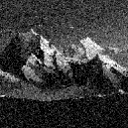

In [5]:
img_initial = Gray.(max.(0.0, min.(1.0, reshape(evaluate_at_points(ph, fe.dh, cond_vec), (128, 128)))))

In [6]:
TV = (x) -> normTV(fe, x)
∇TV = (x) -> assemble_huber_gradient(fe, x)
prox_TV = create_proximal_gradient_step(TV, ∇TV, 0.3; maxiter= 1000)

#73 (generic function with 1 method)

Iter 1 - Loss: 38.5164608172258
Iter 2 - Loss: 38.23167571635594
Iter 3 - Loss: 38.22214101411499
Iter 4 - Loss: 38.10801151683463
Iter 5 - Loss: 38.10801151683463
Iter 6 - Loss: 38.103774926327574
Iter 7 - Loss: 38.103774926327574
Iter 8 - Loss: 37.74672685720843
Iter 9 - Loss: 37.74466594525863
Iter 10 - Loss: 37.74336415510362
Iter 11 - Loss: 37.542471459333726
Iter 12 - Loss: 37.434818347615256
Iter 13 - Loss: 37.42570917159411
Iter 14 - Loss: 37.424842916164025
Iter 15 - Loss: 37.42451965062558
Iter 16 - Loss: 37.3734351493258
Iter 17 - Loss: 37.31704567126308
Iter 18 - Loss: 37.303152510282544
Iter 19 - Loss: 37.301550697944435
Iter 20 - Loss: 37.27877998167274
Iter 21 - Loss: 37.27431397496642
Iter 22 - Loss: 37.27421097606659
Iter 23 - Loss: 37.21654953791723
Iter 24 - Loss: 37.20572909365027
Iter 25 - Loss: 37.14665391435637
Iter 26 - Loss: 37.13808946113752
Iter 27 - Loss: 37.11286695714543
Iter 28 - Loss: 37.11122331024226
Iter 29 - Loss: 37.11121992374024
Iter 30 - Loss: 37

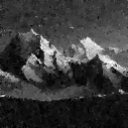

In [7]:
denoised = prox_TV(cond_vec)
denoised_img = Gray.(max.(0.0, min.(1.0, reshape(evaluate_at_points(ph, fe.dh, denoised), (128, 128)))))

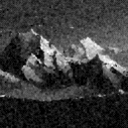

In [33]:
prox_CP = (x) -> prox_tv_chambolle_pock(x,fe,ρ= 2000)
denoised_CP = prox_CP(cond_vec)
denoised_img = Gray.(max.(0.0, min.(1.0, reshape(evaluate_at_points(ph, fe.dh, denoised_CP), (128, 128)))))

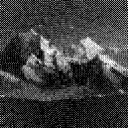

In [36]:
prox_CP = (x) -> prox_tv_chambolle_pock(x,fe,ρ= 100)
denoised_CP = prox_CP(cond_vec)
denoised_img = Gray.(max.(0.0, min.(1.0, reshape(evaluate_at_points(ph, fe.dh, denoised_CP), (128, 128)))))